## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
import xgboost as xgb

## 2. Carga de datos

In [3]:
portatiles = pd.read_csv('train.csv') # cargo el dataset

print(f'Filas: {portatiles.shape[0]} | Columnas: {portatiles.shape[1]}') # imprimo la cantidad de filas y columnas del dataset
portatiles.head()

Filas: 912 | Columnas: 14


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37


## 3. Análisis

Antes de crear el modelo, exploro las variables

### 3.1 Distribución del precio

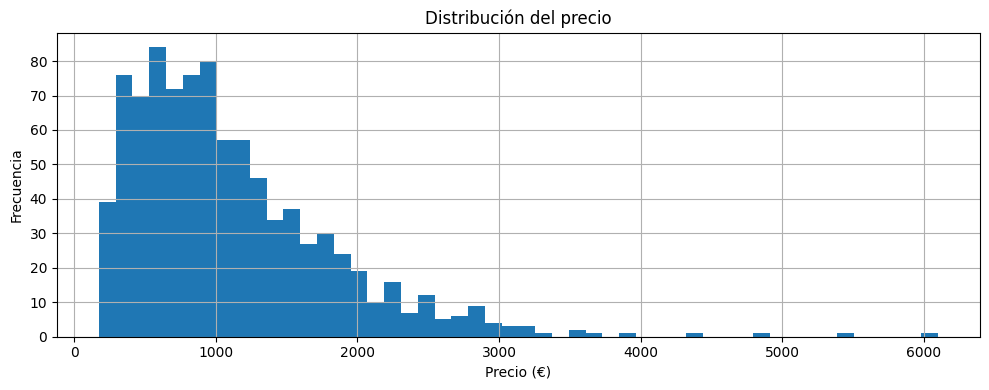

count     912.000000
mean     1108.122873
std       714.597741
min       174.000000
25%       589.000000
50%       949.000000
75%      1458.500000
max      6099.000000
Name: Price_euros, dtype: float64


In [4]:
portatiles['Price_euros'].hist(bins=50, figsize=(10, 4)) # creo un histograma para visualizar la distribución de los precios
plt.title('Distribución del precio')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(portatiles['Price_euros'].describe()) # imprimo las estadísticas descriptivas del precio

### 3.2 Convertimos variables numéricas para el análisis

RAM y Peso vienen como texto. La convierto para poder incluirlas en el análisis.

In [5]:
portatiles['Ram'] = portatiles['Ram'].str.replace('GB', '').astype(int) # limpio la columna 'Ram' eliminando 'GB' y convirtiendo a entero
portatiles['Weight'] = portatiles['Weight'].str.replace('kg', '').astype(float) # limpio la columna 'Weight' eliminando 'kg' y convirtiendo a float



### 3.3 Heatmap de correlaciones

Veo qué variables numéricas se relacionan más con el precio.

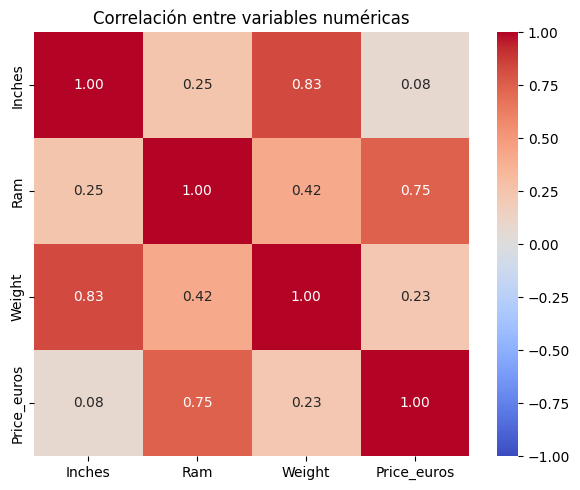

In [6]:
cols_numericas = ['Inches', 'Ram', 'Weight', 'Price_euros'] # selecciono las columnas numéricas para el análisis de correlación

plt.figure(figsize=(6, 5)) # creo un mapa de calor para visualizar la correlación entre las variables numéricas
sns.heatmap(
    portatiles[cols_numericas].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

* RAM y Precio (0.75): esta es la correlación más fuerte. Más RAM, más caro. Tiene sentido.
* Inches y Precio (0.08):  sorprendentemente casi nada. El tamaño de pantalla solo no determina el precio (un 15" barato y un 15" gaming pueden costar muy diferente)
* Weight y  Precio (0.23): relación débil. El peso tampoco dice mucho del precio por sí solo.
* Conclusión: de las 3 variables originales del modelo v1, solo RAM era realmente útil. Por eso el MAE era tan malo al principio.

### 3.4 Pairplot

Relación visual entre todas las variables numéricas y el precio.

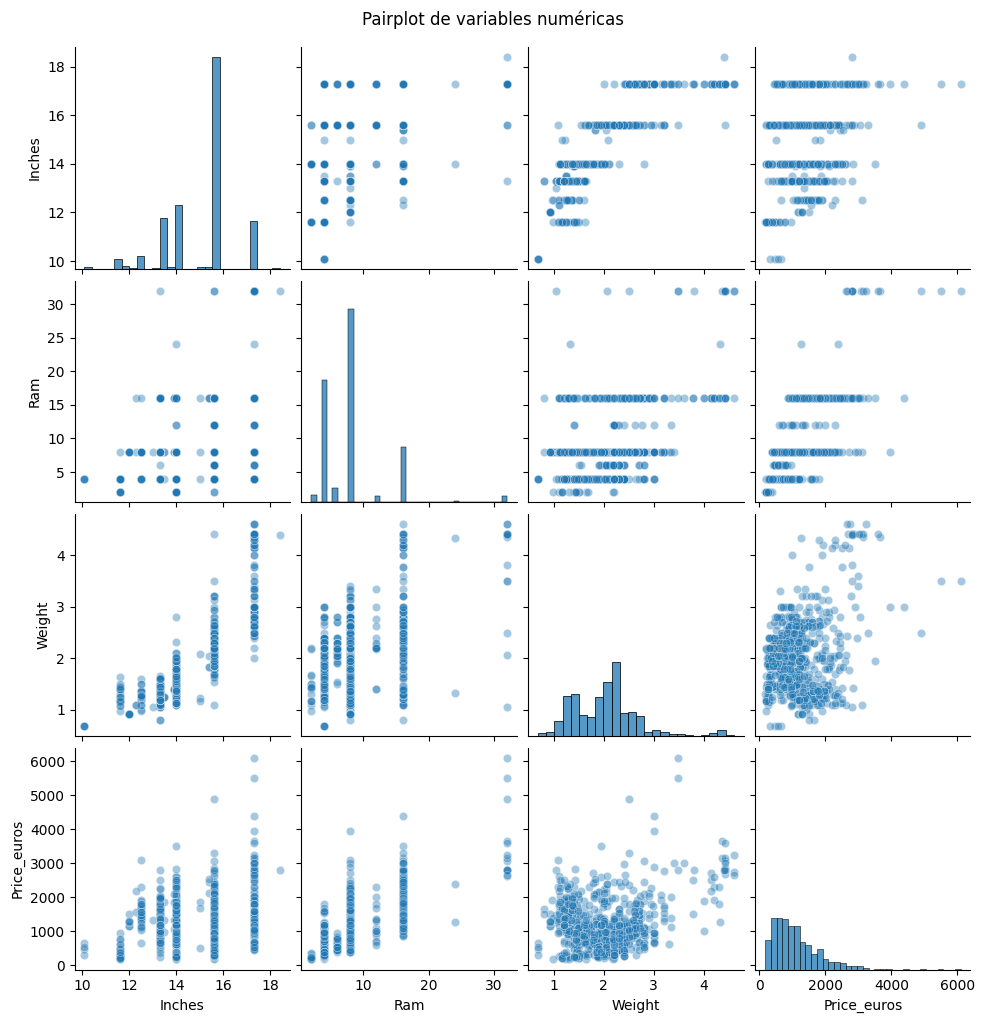

In [7]:
sns.pairplot(portatiles[cols_numericas], plot_kws={'alpha': 0.4}) # creo un pairplot para visualizar las relaciones entre las variables numéricas
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

* RAM y Precio (fila abajo, segunda columna): se ve una tendencia clara hacia arriba. A más RAM, los precios suben. Es la relación más limpia del gráfico.
* Inches y RAM: los valores son discretos (8GB, 16GB, 15.6") por eso los puntos aparecen en líneas perfectas, no dispersos.
* Inches y Precio (última fila, primera columna):  una nube sin forma clara. Confirma que el tamaño de pantalla solo no dice nada del precio.

### 3.5 Precio medio por marca y tipo

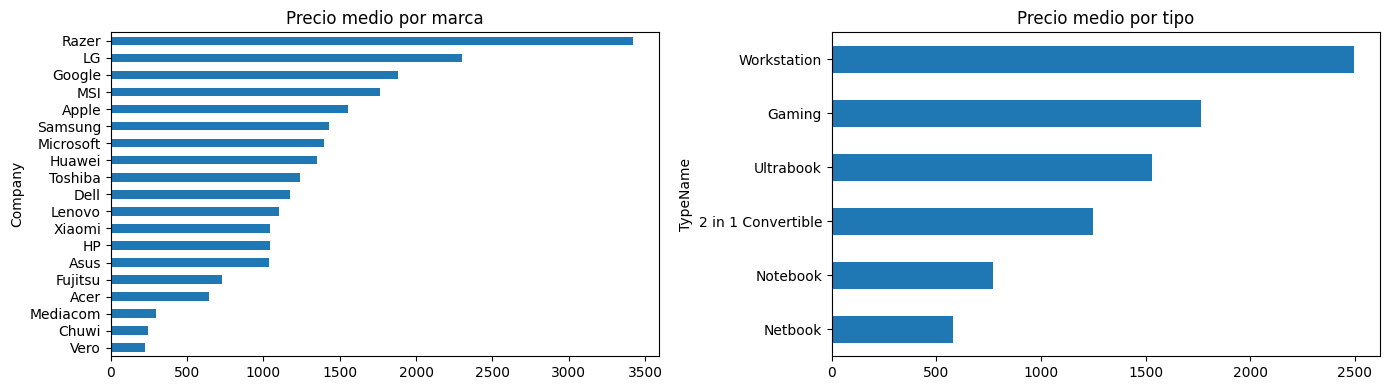

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4)) # creo gráficos de barras para visualizar el precio medio por marca y por tipo

portatiles.groupby('Company')['Price_euros'].mean().sort_values().plot(
    kind='barh', ax=axes[0], title='Precio medio por marca')

portatiles.groupby('TypeName')['Price_euros'].mean().sort_values().plot(
    kind='barh', ax=axes[1], title='Precio medio por tipo')

plt.tight_layout()
plt.show()

#### Tanto la marca como el tipo son variables muy informativas para predecir el precio. Antes del target encoding, cuando se sustituye el nombre de cada marca por el precio medio de esa marca en los datos de entrenamiento, el modelo veía Company = "Razer" (no sabe qué significa) o Company = "Vero" (tampoco). Después del target encoding, el modelo ve Company = 3500 (gama alta) o Company = 150 → (gama budget). En lugar de un texto que no entiende, le damos directamente el precio medio de esa marca. El modelo puede usar ese número para predecir mucho mejor. De ahí que ayude tanto.

## 4. Ingeniería de variables

Crear variables nuevas y útiles a partir de los datos que ya tenemos.

### 4.1 CPU — Marca

In [9]:
portatiles['Cpu_brand'] = portatiles['Cpu'].apply(lambda x: x.split()[0]) # creo una nueva columna 'Cpu_brand' extrayendo la marca del procesador de la columna 'Cpu'

portatiles['Cpu_brand'].value_counts() # imprimo la cantidad de portátiles por cada marca de procesador para identificar las más comunes

Cpu_brand
Intel    872
AMD       40
Name: count, dtype: int64

### 4.2 CPU — Tier de potencia (i3/i5/i7/Xeon)

In [ ]:
# creo una nueva columna 'Cpu_tier' asignando un valor numérico según la potencia del procesador, con un máximo de 6 para los más potentes
portatiles['Cpu_tier'] = (
    portatiles['Cpu']
    .str.contains('Xeon').astype(int) * 6 +
    portatiles['Cpu'].str.contains('i9').astype(int) * 5 +
    portatiles['Cpu'].str.contains('i7').astype(int) * 4 +
    portatiles['Cpu'].str.contains('i5').astype(int) * 3 +
    portatiles['Cpu'].str.contains('i3').astype(int) * 2 +
    portatiles['Cpu'].str.contains('Pentium|Celeron').astype(int) * 1
).clip(upper=6)

### 4.3 CPU — Velocidad en GHz

In [11]:
portatiles['Cpu_ghz'] = portatiles['Cpu'].str.extract(r'(\d+\.\d+)GHz').astype(float) # creo una nueva columna 'Cpu_ghz' extrayendo la frecuencia del 
                                                                                      # procesador en GHz de la columna 'Cpu' para analizar su relación con el precio


### 4.4 CPU — Generación y número de modelo

In [ ]:
# busca un patrón de 4 dígitos seguidos de una letra (ej: 7500U). Coge solo el primer dígito → 7. Ese primer dígito es la generación. Se mete en una nueva columna.
portatiles['Cpu_gen'] = portatiles['Cpu'].str.extract(r'(\d)(\d{3})[A-Z]')[0].astype(float)

# busca exactamente 4 dígitos seguidos de una letra (ej: 7500U). Coge los 4 dígitos completos → 7500. Ese es el número de modelo exacto. Se mete en una nueva columna.
portatiles['Cpu_model_num'] = portatiles['Cpu'].str.extract(r'(\d{4})[A-Z]').astype(float)


### 4.5 CPU — Sufijo (U/H/HQ/HK)

El sufijo indica el tipo de uso: U=bajo consumo (ultrabook), H=alto rendimiento, HQ=quad potente, HK=tope desbloqueado. Del texto "Intel Core i7 7500U" extraemos el sufijo final de la letra y le asignamos un número según su potencia: HK → 4 (el más potente, desbloqueado), HQ → 3 (quad core potente, gaming), H → 2 (alto rendimiento), U → 1 (bajo consumo, ultrabook). El .clip(upper=4) asegura que ningún valor supere 4, por si algún procesador coincide con varios patrones a la vez. El resultado es una columna nueva con un número del 1 al 4 que indica qué tan potente es el procesador más allá del simple i3/i5/i7

In [ ]:
# creo una nueva columna 'Cpu_suffix_tier' asignando un valor numérico según el sufijo del modelo (H, HQ, HK, U), con un máximo de 4 para los más potentes
portatiles['Cpu_suffix_tier'] = (
    portatiles['Cpu'].str.contains(r'\d{4}HK').astype(int) * 4 +
    portatiles['Cpu'].str.contains(r'\d{4}HQ').astype(int) * 3 +
    portatiles['Cpu'].str.contains(r'\d{4}H[^KQ]').astype(int) * 2 +
    portatiles['Cpu'].str.contains(r'\d{4}U').astype(int) * 1
).clip(upper=4)

### 4.6 GPU — Marca

In [ ]:
# creo una nueva columna 'Gpu_brand' extrayendo la marca de la tarjeta gráfica de la columna 'Gpu' para analizar su relación con el precio
portatiles['Gpu_brand'] = portatiles['Gpu'].apply(lambda x: x.split()[0])


### 4.7 GPU — Dedicada o integrada

In [ ]:
# creo una nueva columna 'Gpu_is_dedicated' que vale 1 si la GPU es dedicada (no integrada) y 0 si es integrada, basándome en si el nombre de la GPU contiene palabras clave de GPUs integradas comunes
portatiles['Gpu_is_dedicated'] = (~portatiles['Gpu'].str.contains('HD Graphics|UHD Graphics|Iris')).astype(int)

### 4.8 GPU — Tier de potencia y número de modelo

In [ ]:
# creo una nueva columna 'Gpu_tier' asignando un valor numérico según la potencia de la tarjeta gráfica, con un máximo de 6 para las más potentes
portatiles['Gpu_tier'] = (
    portatiles['Gpu'].str.contains('1080').astype(int) * 6 +
    portatiles['Gpu'].str.contains('1070').astype(int) * 5 +
    portatiles['Gpu'].str.contains('1060').astype(int) * 4 +
    portatiles['Gpu'].str.contains('1050 Ti').astype(int) * 3 +
    (portatiles['Gpu'].str.contains('1050') & ~portatiles['Gpu'].str.contains('1050 Ti')).astype(int) * 2 +
    portatiles['Gpu'].str.contains('MX').astype(int) * 2 +
    portatiles['Gpu'].str.contains('Quadro|Pro').astype(int) * 5 +
    portatiles['Gpu'].str.contains('HD Graphics|UHD Graphics|Iris').astype(int) * 0
).clip(upper=6)
# se busca un patrón de 3 o 4 dígitos en el nombre de la GPU (ej: GTX 1050, RTX 2060). Coge esos dígitos → 1050, 2060. Ese es el número de modelo aproximado. Se mete en una nueva columna.
portatiles['Gpu_model_num'] = portatiles['Gpu'].str.extract(r'(\d{3,4})').astype(float)


### 4.9 Pantalla — Píxeles totales y PPI

Extrigo el ancho y alto de la resolución para calcular los píxeles totales de la pantalla y su calidad real en píxeles por pulgada. Esto se hace porque dos portátiles pueden tener la misma resolución pero pantallas muy distintas — un 4K en 13" es mucho más nítido que un 4K en 17", y esa calidad real influye en el precio.

In [19]:
w = portatiles['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')[0].astype(float)
h = portatiles['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')[1].astype(float)
portatiles['Screen_pixels'] = w * h
portatiles['PPI'] = (np.sqrt(w**2 + h**2) / portatiles['Inches']).round(1)

### 4.10 Pantalla — Flags de tipo

Miro si el texto de la resolución contiene esas palabras y crea una columna con 1 si aparece y 0 si no. Por ejemplo "IPS Panel 1920x1080" = Is_IPS = 1.

In [29]:
portatiles['Is_IPS']         = portatiles['ScreenResolution'].str.contains('IPS').astype(int)
portatiles['Is_touchscreen'] = portatiles['ScreenResolution'].str.contains('Touchscreen').astype(int)
portatiles['Is_4K']          = portatiles['ScreenResolution'].str.contains('4K').astype(int)
portatiles['Is_retina']      = portatiles['ScreenResolution'].str.contains('Retina').astype(int)

### 4.11 Almacenamiento

In [ ]:
# detecto qué tipo de almacenamiento tiene cada portátil y cuántos GB en total
portatiles['Has_SSD']    = portatiles['Memory'].str.contains('SSD').astype(int)
portatiles['Has_HDD']    = portatiles['Memory'].str.contains('HDD').astype(int)
portatiles['Has_hybrid'] = ((portatiles['Has_SSD'] == 1) & (portatiles['Has_HDD'] == 1)).astype(int)
portatiles['Has_flash']  = portatiles['Memory'].str.contains('Flash').astype(int)
portatiles['Storage_GB'] = (
    portatiles['Memory'].str.extractall(r'(\d+)GB').astype(int).groupby(level=0).sum()[0] +
    portatiles['Memory'].str.extractall(r'(\d+)TB').astype(int).groupby(level=0).sum()[0].multiply(1000)
).fillna(0)
portatiles['SSD_GB'] = portatiles['Memory'].str.extract(r'(\d+)GB SSD').astype(float).fillna(0)

### 4.12 OS, marca y keywords de producto

* OS_group: agrupo los sistemas operativos en categorías simples (Win10, Mac, Linux...)
* Company_tier: clasifico las marcas en premium (2), mid (1) o budget (0)
* is_gaming/is_pro/is_macbook/is_workstation: detecto el tipo de portátil por palabras clave del nombre del producto

In [21]:
os_map = {
    'Windows 10': 'Win10', 'macOS': 'Mac', 'Mac OS X': 'Mac',
    'Linux': 'Linux', 'Chrome OS': 'Chrome', 'No OS': 'NoOS',
    'Windows 7': 'WinOld', 'Windows 10 S': 'Win10'
}

portatiles['OS_group'] = portatiles['OpSys'].map(os_map).fillna('Other')

premium = ['Apple', 'Razer', 'MSI', 'Microsoft', 'LG', 'Huawei']
mid     = ['Dell', 'HP', 'Lenovo', 'Toshiba', 'Samsung', 'Fujitsu']

portatiles['Company_tier'] = portatiles['Company'].map(
    lambda s: 2 if s in premium else (1 if s in mid else 0))

portatiles['is_gaming']      = portatiles['Product'].str.lower().str.contains('alienware|rog|predator|nitro|legion').astype(int)
portatiles['is_pro']         = portatiles['Product'].str.lower().str.contains('pro|thinkpad|latitude|elitebook|xps|zenbook').astype(int)
portatiles['is_macbook']     = portatiles['Product'].str.lower().str.contains('macbook').astype(int)
portatiles['is_workstation'] = portatiles['Product'].str.lower().str.contains('workstation|zbook|precision|probook').astype(int)

### 4.13 Interacciones

In [ ]:
# creo tres variables nuevas multiplicando variables entre sí, porque la combinación de dos características puede ser más informativa que cada una por separado.
portatiles['Ram_x_GpuTier']  = portatiles['Ram'] * portatiles['Gpu_tier']
portatiles['Cpu_x_Gpu']      = portatiles['Cpu_tier'] * portatiles['Gpu_tier']
portatiles['Cpu_ghz_x_tier'] = portatiles['Cpu_ghz'] * portatiles['Cpu_tier']

## 5. Heatmap con todas las features numéricas

Reviso las correlaciones después del trabajo de las variables.

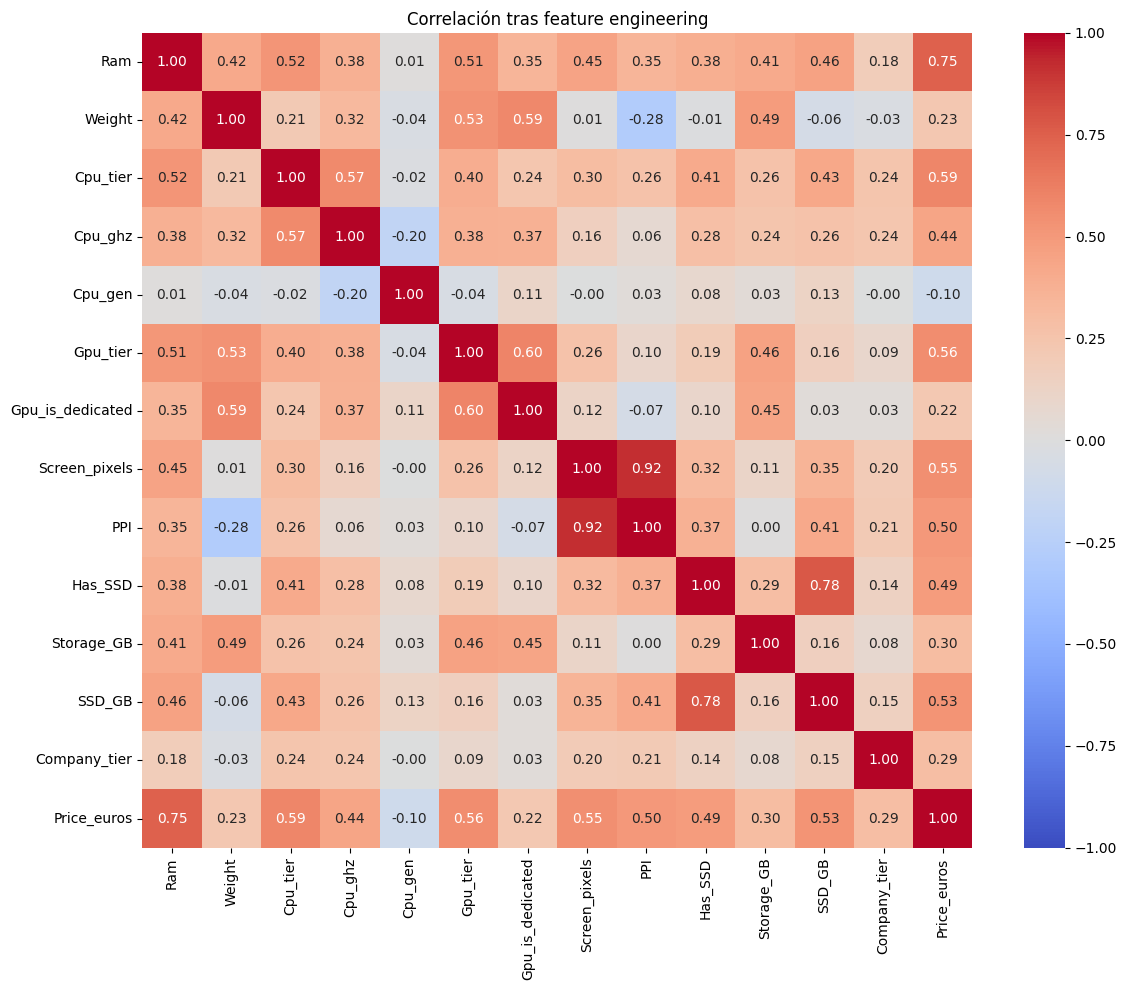

In [ ]:
cols_fe = ['Ram', 'Weight', 'Cpu_tier', 'Cpu_ghz', 'Cpu_gen',
           'Gpu_tier', 'Gpu_is_dedicated', 'Screen_pixels', 'PPI',
           'Has_SSD', 'Storage_GB', 'SSD_GB', 'Company_tier', 'Price_euros']
# visualizo la correlación entre las variables numéricas tras el trabajo de variables para ver si se han creado nuevas relaciones útiles para predecir el precio
plt.figure(figsize=(12, 10))
sns.heatmap(portatiles[cols_fe].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación tras feature engineering')
plt.tight_layout()
plt.show()

* RAM (0.75): sigue siendo la más correlacionada con el precio.
* Cpu_tier (0.59): el tier del procesador importa mucho.
* Gpu_tier (0.56): la potencia de la GPU también.
* Screen_pixels (0.55) y SSD_GB (0.53): pantalla grande y SSD grande suben el precio.
* Cpu_gen (-0.10): la generación del procesador casi no correlaciona, sorprendente.

## 6. Encoding

* Aplico el target encoding y sustituyo cada categoría de texto por el precio medio de esa categoría.
* El smooth mezcla la media de cada categoría con la media global (gm) para evitar que categorías con pocos ejemplos tengan valores extremos.
* El resultado son tres columnas nuevas: Company_te, TypeName_te y OS_group_te con el precio medio de cada marca, tipo y sistema operativo.

In [25]:
y = portatiles['Price_euros']
gm = y.mean()

te_cols = ['Company', 'TypeName', 'OS_group']

for col in te_cols:
    stats = portatiles.groupby(col)['Price_euros'].agg(['mean', 'count'])
    stats['smooth'] = (stats['mean'] * stats['count'] + gm * 10) / (stats['count'] + 10)
    portatiles[col + '_te'] = portatiles[col].map(stats['smooth']).fillna(gm).astype(float)

* Convierto la marca de CPU y GPU de texto a número de forma simple.
* A diferencia del target encoding, aquí el número es arbitrario, ya que no tiene relación con el precio. Lo uso así porque CPU y GPU brand tienen pocas categorías y el modelo puede aprender la relación por sí solo

In [27]:
cat_cols = ['Cpu_brand', 'Gpu_brand']

for col in cat_cols:
    le = LabelEncoder()
    le.fit(portatiles[col])
    portatiles[col + '_enc'] = le.transform(portatiles[col])


## 7. Selección de features

In [ ]:
# finalmente, selecciono las columnas que voy a usar como características para el modelo, incluyendo las nuevas variables numéricas y las codificaciones de las variables categóricas
num_cols = [
    'Inches', 'Ram', 'Weight',
    'Cpu_ghz', 'Cpu_gen', 'Cpu_tier', 'Cpu_suffix_tier', 'Cpu_model_num',
    'Screen_pixels', 'PPI', 'Is_touchscreen', 'Is_IPS', 'Is_4K', 'Is_retina',
    'Has_SSD', 'Has_HDD', 'Has_hybrid', 'Has_flash', 'Storage_GB', 'SSD_GB',
    'Gpu_is_dedicated', 'Gpu_tier', 'Gpu_model_num', 'Company_tier',
    'is_gaming', 'is_pro', 'is_macbook', 'is_workstation',
    'Ram_x_GpuTier', 'Cpu_x_Gpu', 'Cpu_ghz_x_tier'
]
# las variables finales para el modelo incluyen las características numéricas originales, las nuevas variables creadas a partir de ellas, y las codificaciones de las variables categóricas.
feature_cols = num_cols + [c + '_te' for c in te_cols] + [c + '_enc' for c in cat_cols]
# selecciono las columnas finales para el modelo
X = portatiles[feature_cols]
# imprimo la cantidad total de variables que se van a usar como características para el modelo
print(f'Variables totales: {len(feature_cols)}')

Variables totales: 36


## 8. Validación cruzada

In [ ]:
# configuro el modelo XGBoost y realizo validación cruzada con KFold para evaluar su rendimiento utilizando el MAE como métrica
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# configuro el modelo XGBoost con hiperparámetros específicos para intentar mejorar su rendimiento, como un número elevado de estimadores, una tasa de aprendizaje moderada, y limitaciones en la profundidad y el muestreo de las características para evitar el sobreajuste.
modelo = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=11,
    verbosity=0
)
# realizo validación cruzada con KFold y calculo el MAE para cada fold, almacenando los resultados en una lista
maes = []
for tr_idx, val_idx in kf.split(X):
    modelo.fit(X.iloc[tr_idx], np.log1p(y.iloc[tr_idx]))
    pred = np.expm1(modelo.predict(X.iloc[val_idx]))
    maes.append(mean_absolute_error(y.iloc[val_idx], pred))
# imprimo el MAE medio y su desviación estándar para evaluar el rendimiento del modelo en la validación cruzada
print(f'CV MAE: {np.mean(maes):.2f} euros (+/- {np.std(maes):.2f})')

CV MAE: 139.80 euros (+/- 13.22)


## 9. Entrenamiento final

In [ ]:
modelo.fit(X, np.log1p(y))

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Realizamos el logaritmo de y porque la mayoría de precios están entre 500-2000€, pero hay unos pocos de 5000-6000€ que distorsionan mucho el modelo. Con el logaritmo se comprime esa escala y la diferencia entre 500 y 1000€ pesa igual que la diferencia entre 2000 y 4000€. El modelo aprende mejor así. Luego, al predecir, se hace np.expm1 para deshacer el logaritmo y volver a euros reales.

## 10. Predicciones

Aquí se hacen dos cosas:
* Primero: aplico exactamente el mismo trabajo de variables al test que hicimos antes con el train, ya que el modelo necesita ver los datos en el mismo formato con el que aprendió.
* Segundo: predigo el precio de cada portátil del test y lo guardo en el archivo con el formato correcto para entregar en Kaggle.

In [36]:
# cargo el test y el sample submission
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

# aplico exactamente el mismo feature engineering que al train
test['Ram'] = test['Ram'].str.replace('GB', '').astype(int)
test['Weight'] = test['Weight'].str.replace('kg', '').astype(float)
test['Cpu_brand'] = test['Cpu'].apply(lambda x: x.split()[0])
test['Cpu_tier'] = (
    test['Cpu'].str.contains('Xeon').astype(int) * 6 +
    test['Cpu'].str.contains('i9').astype(int) * 5 +
    test['Cpu'].str.contains('i7').astype(int) * 4 +
    test['Cpu'].str.contains('i5').astype(int) * 3 +
    test['Cpu'].str.contains('i3').astype(int) * 2 +
    test['Cpu'].str.contains('Pentium|Celeron').astype(int) * 1
).clip(upper=6)
test['Cpu_ghz'] = test['Cpu'].str.extract(r'(\d+\.\d+)GHz').astype(float)
test['Cpu_gen'] = test['Cpu'].str.extract(r'(\d)(\d{3})[A-Z]')[0].astype(float)
test['Cpu_model_num'] = test['Cpu'].str.extract(r'(\d{4})[A-Z]').astype(float)
test['Cpu_suffix_tier'] = (
    test['Cpu'].str.contains(r'\d{4}HK').astype(int) * 4 +
    test['Cpu'].str.contains(r'\d{4}HQ').astype(int) * 3 +
    test['Cpu'].str.contains(r'\d{4}H[^KQ]').astype(int) * 2 +
    test['Cpu'].str.contains(r'\d{4}U').astype(int) * 1
).clip(upper=4)
test['Gpu_brand'] = test['Gpu'].apply(lambda x: x.split()[0])
test['Gpu_is_dedicated'] = (~test['Gpu'].str.contains('HD Graphics|UHD Graphics|Iris')).astype(int)
test['Gpu_tier'] = (
    test['Gpu'].str.contains('1080').astype(int) * 6 +
    test['Gpu'].str.contains('1070').astype(int) * 5 +
    test['Gpu'].str.contains('1060').astype(int) * 4 +
    test['Gpu'].str.contains('1050 Ti').astype(int) * 3 +
    (test['Gpu'].str.contains('1050') & ~test['Gpu'].str.contains('1050 Ti')).astype(int) * 2 +
    test['Gpu'].str.contains('MX').astype(int) * 2 +
    test['Gpu'].str.contains('Quadro|Pro').astype(int) * 5
).clip(upper=6)
test['Gpu_model_num'] = test['Gpu'].str.extract(r'(\d{3,4})').astype(float)
w = test['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')[0].astype(float)
h = test['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')[1].astype(float)
test['Screen_pixels'] = w * h
test['PPI'] = (np.sqrt(w**2 + h**2) / test['Inches']).round(1)
test['Is_IPS']         = test['ScreenResolution'].str.contains('IPS').astype(int)
test['Is_touchscreen'] = test['ScreenResolution'].str.contains('Touchscreen').astype(int)
test['Is_4K']          = test['ScreenResolution'].str.contains('4K').astype(int)
test['Is_retina']      = test['ScreenResolution'].str.contains('Retina').astype(int)
test['Has_SSD']    = test['Memory'].str.contains('SSD').astype(int)
test['Has_HDD']    = test['Memory'].str.contains('HDD').astype(int)
test['Has_hybrid'] = ((test['Has_SSD'] == 1) & (test['Has_HDD'] == 1)).astype(int)
test['Has_flash']  = test['Memory'].str.contains('Flash').astype(int)
test['Storage_GB'] = (
    test['Memory'].str.extractall(r'(\d+)GB').astype(int).groupby(level=0).sum()[0] +
    test['Memory'].str.extractall(r'(\d+)TB').astype(int).groupby(level=0).sum()[0].multiply(1000)
).fillna(0)
test['SSD_GB'] = test['Memory'].str.extract(r'(\d+)GB SSD').astype(float).fillna(0)
test['OS_group'] = test['OpSys'].map(os_map).fillna('Other')
test['Company_tier'] = test['Company'].map(lambda s: 2 if s in premium else (1 if s in mid else 0))
test['is_gaming']      = test['Product'].str.lower().str.contains('alienware|rog|predator|nitro|legion').astype(int)
test['is_pro']         = test['Product'].str.lower().str.contains('pro|thinkpad|latitude|elitebook|xps|zenbook').astype(int)
test['is_macbook']     = test['Product'].str.lower().str.contains('macbook').astype(int)
test['is_workstation'] = test['Product'].str.lower().str.contains('workstation|zbook|precision|probook').astype(int)
test['Ram_x_GpuTier']  = test['Ram'] * test['Gpu_tier']
test['Cpu_x_Gpu']      = test['Cpu_tier'] * test['Gpu_tier']
test['Cpu_ghz_x_tier'] = test['Cpu_ghz'] * test['Cpu_tier']
for col in te_cols:
    stats = portatiles.groupby(col)['Price_euros'].agg(['mean', 'count'])
    stats['smooth'] = (stats['mean'] * stats['count'] + gm * 10) / (stats['count'] + 10)
    test[col + '_te'] = test[col].map(stats['smooth']).fillna(gm).astype(float)
for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([portatiles[col], test[col]]))
    test[col + '_enc'] = le.transform(test[col])
X_test = test[feature_cols]

test['Price_euros'] = np.expm1(modelo.predict(X_test))
submission = sample[['id']].merge(test[['id', 'Price_euros']], on='id')
submission.head(10)

,id,Price_euros
0,1014,291.079437
1,845,997.611572
2,1151,1976.052002
3,1265,743.565002
4,573,2406.964844
5,521,1859.513550
6,316,1136.005493
7,133,2362.804688
8,1099,1548.097046
9,605,1402.388550


## 11. Feature Importance

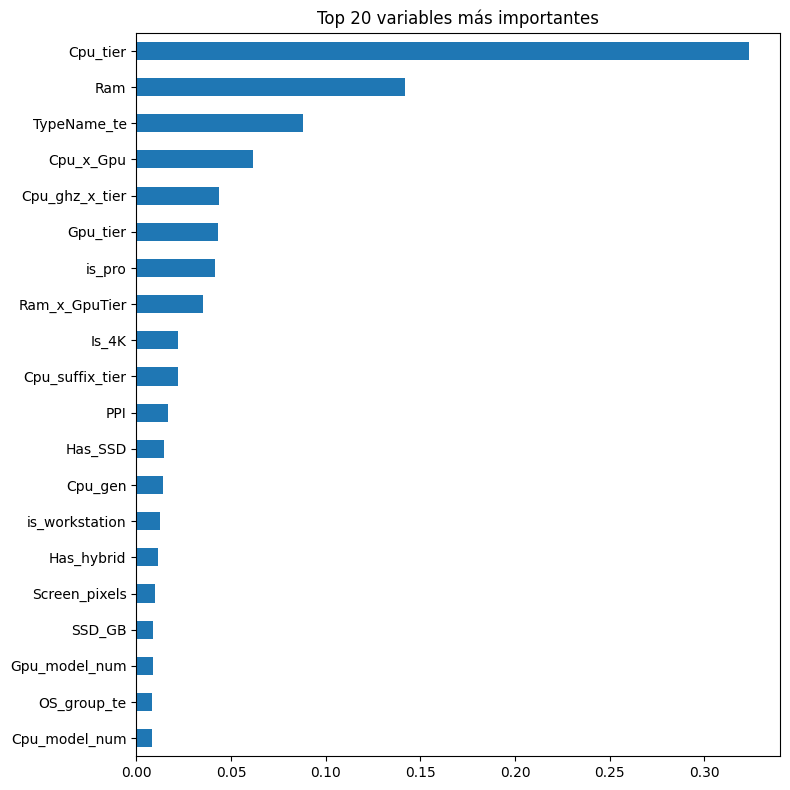

In [ ]:
# creo una serie con la importancia de cada variable según el modelo para visualizar cuáles son las características más relevantes para predecir el precio
importances = pd.Series(modelo.feature_importances_, index=feature_cols) 
# ordeno las importancias de menor a mayor y visualizo las 20 variables más importantes en un gráfico de barras horizontal para identificar cuáles son las características que más influyen en la predicción del precio.
importances.sort_values().tail(20).plot(
    kind='barh', figsize=(8, 8), title='Top 20 variables más importantes')
plt.tight_layout()
plt.show()

Las tres variables que más influyen en el precio son el tier del procesador, la RAM y el tipo de portátil, lo cual parece tener sentido. Las interacciones que creamos (Cpu_x_Gpu, Cpu_ghz_x_tier, Ram_x_GpuTier) también aparecen arriba, confirmando que la combinación de especificaciones importa más que cada una por separado.

## 12. Guardar modelo y archivo

In [39]:
pickle.dump(modelo, open('v7_XGBoost.pkl', 'wb'))
submission.to_csv('submission_v7.csv', index=False)